<a href="https://colab.research.google.com/github/ANU-3006/Customer_churn-Prediction/blob/main/Customer_CChurn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler,LabelBinarizer
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,recall_score,f1_score,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as make_pipeline_imb

import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install --upgrade scikit-learn xgboost numpy

  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 47.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.2 which is incompatible.


In [112]:
df = pd.read_csv('Churn_Modelling (1).csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [44]:
df.isna().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [45]:
print(df["Gender"].unique())

['Female' 'Male']


In [46]:
numerical_features_list = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

for col in df.columns:
    if col not in numerical_features_list:
        print(col, df[col].unique())
        print("-"*50)

RowNumber [    1     2     3 ...  9998  9999 10000]
--------------------------------------------------
CustomerId [15634602 15647311 15619304 ... 15584532 15682355 15628319]
--------------------------------------------------
Surname ['Hargrave' 'Hill' 'Onio' ... 'Kashiwagi' 'Aldridge' 'Burbidge']
--------------------------------------------------
Geography ['France' 'Spain' 'Germany']
--------------------------------------------------
Gender ['Female' 'Male']
--------------------------------------------------
HasCrCard [1 0]
--------------------------------------------------
IsActiveMember [1 0]
--------------------------------------------------
Exited [1 0]
--------------------------------------------------


In [47]:
print(df["Exited"].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


In [ ]:
#EDA

In [48]:
df.shape

(10000, 14)

In [49]:
print(df.columns)

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


In [50]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


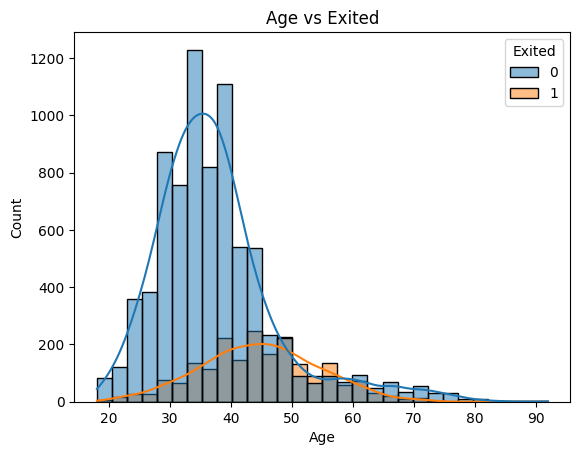

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x="Age", hue="Exited", bins=30, kde=True)
plt.title("Age vs Exited")
plt.show()

In [52]:
import matplotlib.pyplot as plt

def plot_histogram(data, column):
    plt.figure(figsize=(6,4))
    plt.hist(data[column], bins=20)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

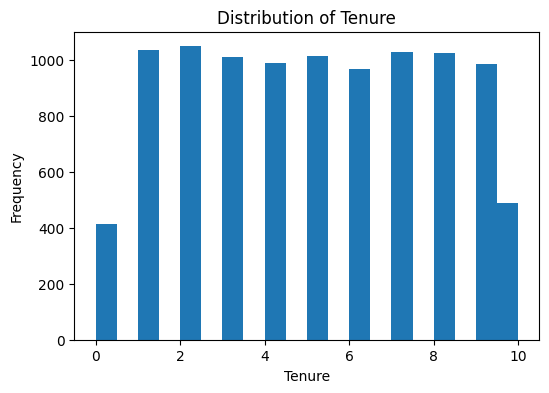

In [53]:
plot_histogram(df, "Tenure")

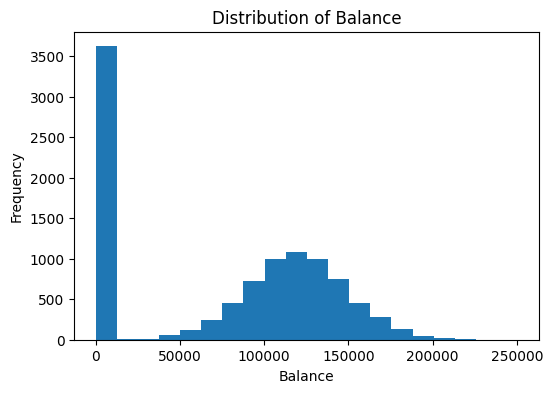

In [54]:
plot_histogram(df, "Balance")

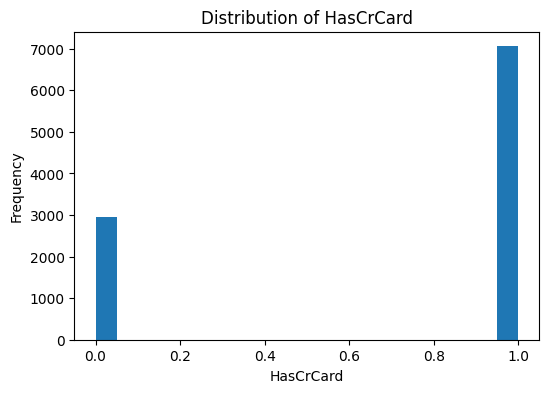

In [55]:
plot_histogram(df, "HasCrCard")

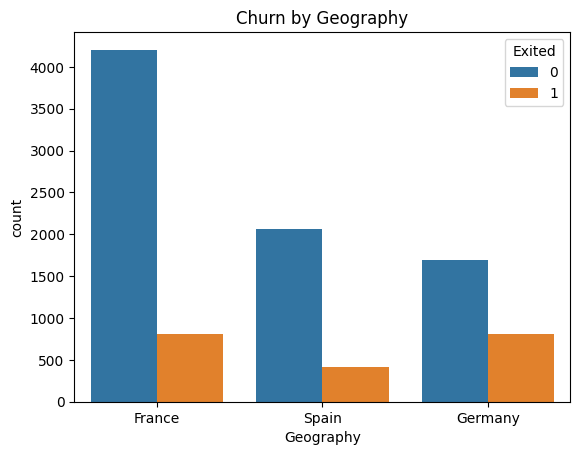

In [56]:
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title('Churn by Geography')
plt.show()

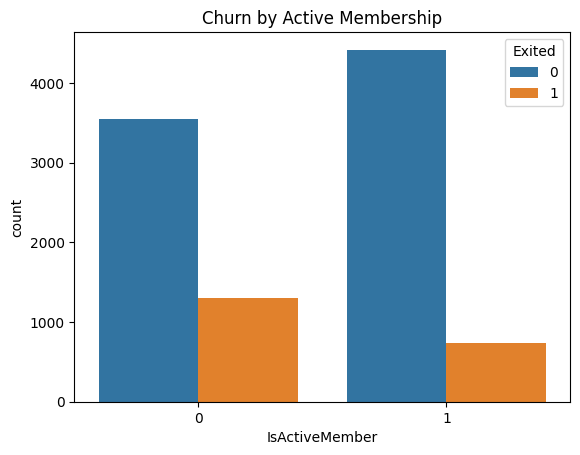

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="IsActiveMember", hue="Exited", data=df)
plt.title("Churn by Active Membership")
plt.show()

In [58]:
df.groupby("IsActiveMember")["Exited"].mean()

,Exited
IsActiveMember,
0,0.268509
1,0.142691


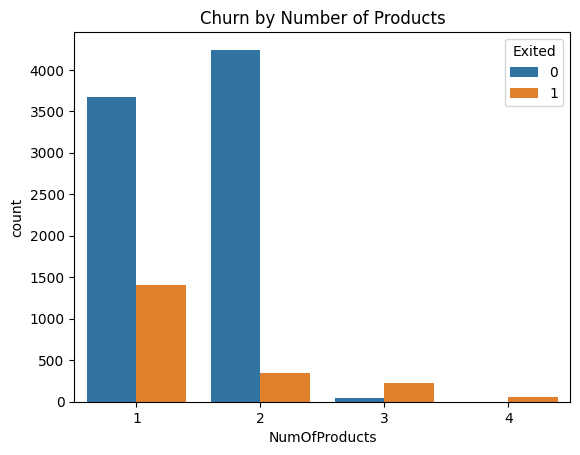

In [59]:
sns.countplot(x="NumOfProducts", hue="Exited", data=df)
plt.title("Churn by Number of Products")
plt.show()

In [60]:
df.groupby("NumOfProducts")["Exited"].mean()

,Exited
NumOfProducts,
1,0.277144
2,0.075817
3,0.827068
4,1.000000


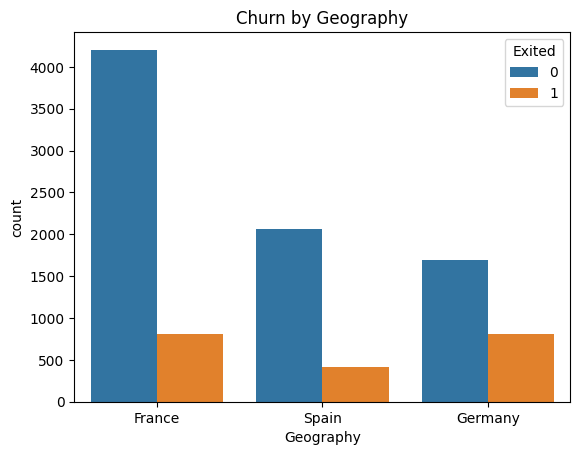

In [61]:
sns.countplot(x="Geography", hue="Exited", data=df)
plt.title("Churn by Geography")
plt.show()

In [62]:
df.groupby("Geography")["Exited"].mean()

,Exited
Geography,
France,0.161548
Germany,0.324432
Spain,0.166734


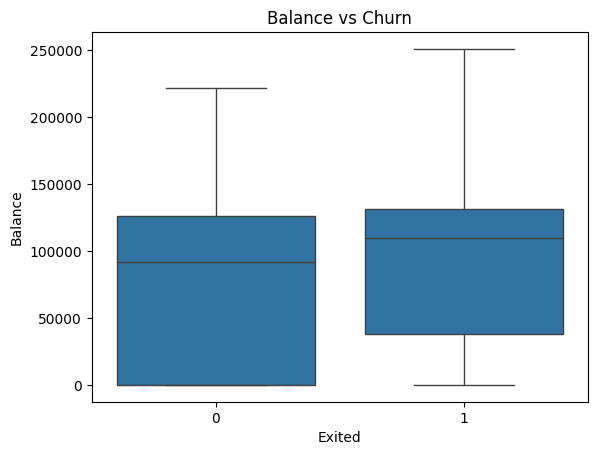

In [63]:
sns.boxplot(x="Exited", y="Balance", data=df)
plt.title("Balance vs Churn")
plt.show()

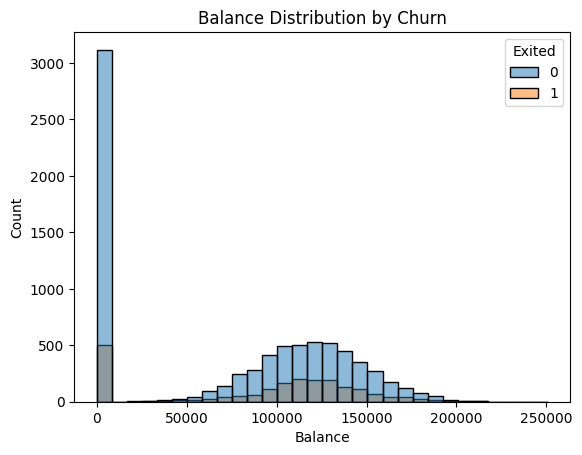

In [64]:
sns.histplot(data=df, x="Balance", hue="Exited", bins=30)
plt.title("Balance Distribution by Churn")
plt.show()

In [65]:
df["Exited"] = df["Exited"].replace({"Yes": 1, "No": 0})

In [26]:
df.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [66]:
print(df["Exited"].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


In [67]:
object_columns = df.select_dtypes(include="object").columns

In [107]:
print(object_columns)

Index(['Surname', 'Geography', 'Gender'], dtype='object')


In [108]:
df['Exited'].value_counts(normalize=True) * 100

,proportion
Exited,
0,79.63
1,20.37


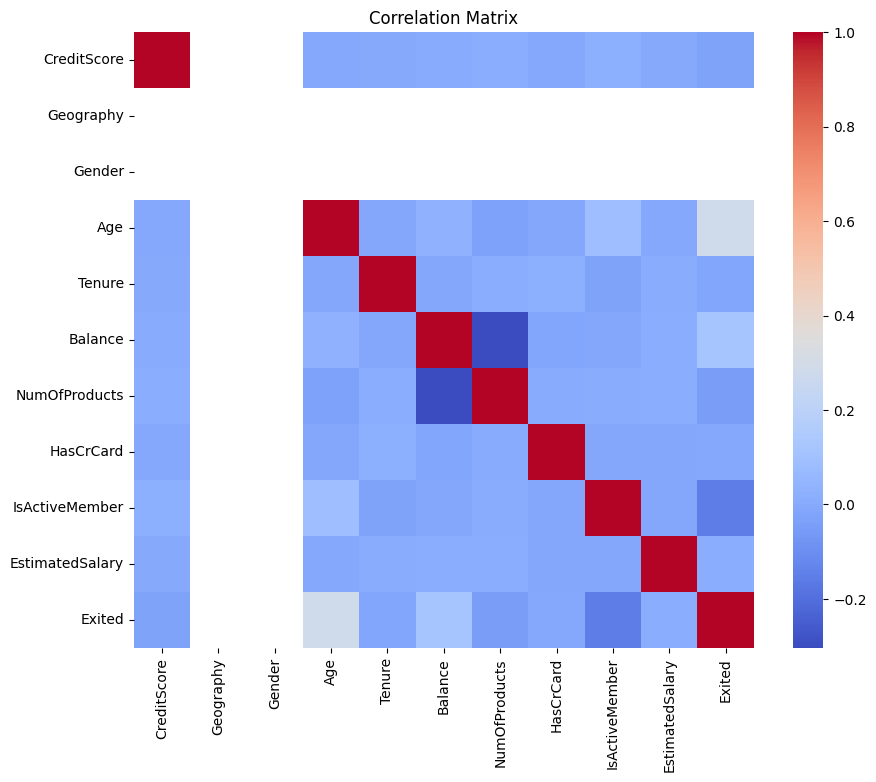

In [109]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

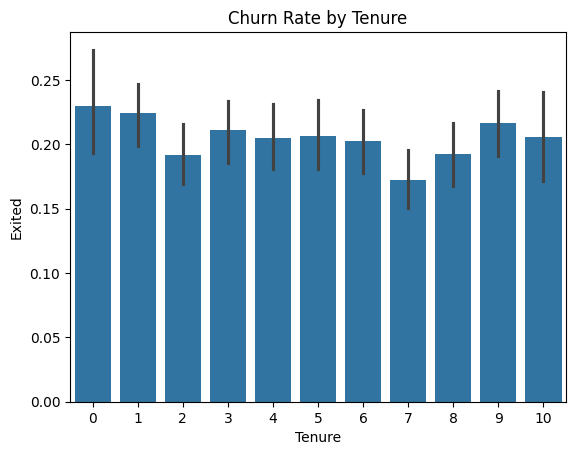

In [110]:
sns.barplot(x='Tenure', y='Exited', data=df)
plt.title("Churn Rate by Tenure")
plt.show()

In [113]:
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

In [152]:
X = df[['CreditScore',
        'Geography',
        'Gender',
        'Age',
        'Tenure',
        'Balance',
        'NumOfProducts',
        'HasCrCard',
        'IsActiveMember',
        'EstimatedSalary']]
y = df['Exited']

In [153]:
X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True)

In [156]:
print(X.shape)

(10000, 11)


In [157]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [159]:
print(X_train.shape)

(8000, 11)


In [160]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [161]:
print(X_train.shape)

(8000, 11)


In [162]:
from sklearn.impute import SimpleImputer

# Fill missing values with the median (or mean)
imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [163]:
print(X_train.shape)

(8000, 11)


In [164]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [165]:
print(X_train_res.shape)

(12712, 11)


In [166]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import numpy as np

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        eval_metric='auc',
        scale_pos_weight=scale_pos_weight,
        random_state=42
    )
}

print("Cross Validation Results (ROC-AUC):\n")

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_res,
        y_train_res,
        cv=5,
        scoring="roc_auc"
    )

    cv_results[name] = np.mean(scores)
    print(f"{name}: {np.mean(scores):.3f}")

Cross Validation Results (ROC-AUC):

Logistic Regression: 0.773
Random Forest: 0.963
XGBoost: 0.959


In [140]:
best_model_name = max(cv_results, key=cv_results.get)
print("\nBest Model:", best_model_name)

best_model = models[best_model_name]
best_model.fit(X_train_res, y_train_res)


Best Model: Random Forest


RandomForestClassifier(class_weight='balanced', random_state=42)

In [169]:
# Number of features the model expects
models["Random Forest"].fit(X_train, y_train)

print(models["Random Forest"].n_features_in_)

11


In [170]:
y_prob = best_model.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.5).astype(int)

print("\nFinal Test Results:\n")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))



Final Test Results:

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1607
           1       0.58      0.59      0.59       393

    accuracy                           0.84      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.84      0.84      0.84      2000

ROC-AUC: 0.8494523799344788


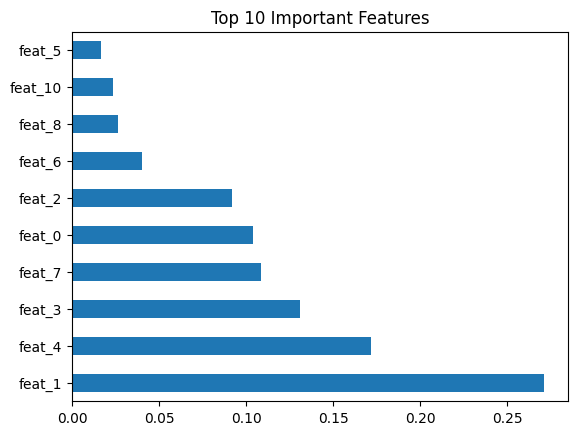

In [143]:
import pandas as pd
import matplotlib.pyplot as plt
columns = X.columns
import pandas as pd

# For X_train after scaling or SMOTE
X_train = pd.DataFrame(X_train, columns=[f'feat_{i}' for i in range(X_train.shape[1])])
X_test  = pd.DataFrame(X_test, columns=[f'feat_{i}' for i in range(X_test.shape[1])])
if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.Series(
        best_model.feature_importances_,
        index=X_train.columns  # Use processed X_train columns
    ).sort_values(ascending=False)

    feature_importance.head(10).plot(kind='barh')
    plt.title("Top 10 Important Features")
    plt.show()
else:
    print("Feature importance not available for this model")

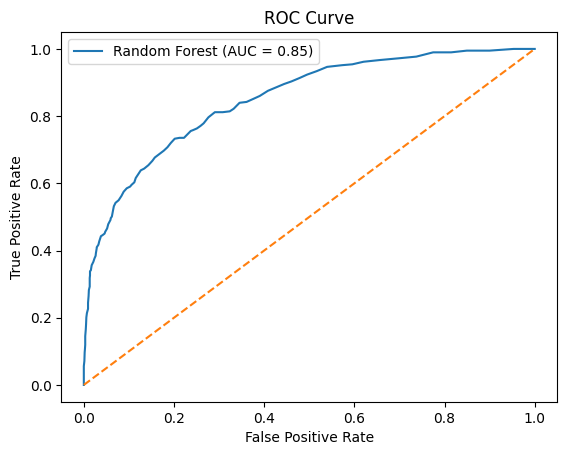

In [144]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

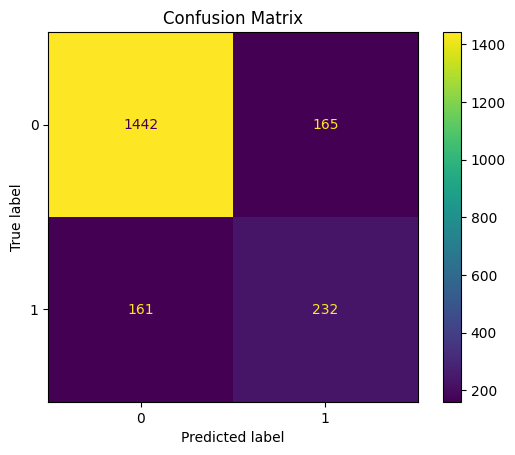

In [145]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

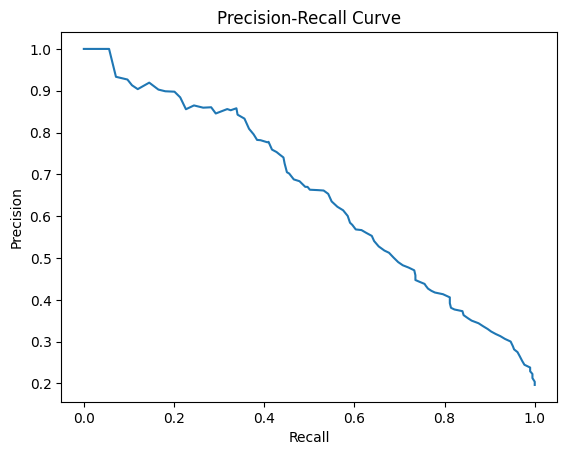

In [146]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [147]:
print(scaler.n_features_in_)
print(X.columns.tolist())

11
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [148]:
import pickle

# Train final model on full training data
final_model = best_model

# Save model
with open("churn_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

# Save scaler (if you used StandardScaler)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [149]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [150]:
import pickle

model_path = "/content/drive/MyDrive/churn_model.pkl"
scaler_path = "/content/drive/MyDrive/scaler.pkl"

with open(model_path, "wb") as f:
    pickle.dump(final_model, f)

with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

print("Saved to Google Drive successfully!")

Saved to Google Drive successfully!
